In [114]:
# papermill parameters

# i/o
input_ohlcv_file='binance-1d-spot-stable-pairs.parquet'
input_gjr_file='binance-1d-spot-volatility-forecast.parquet'

output_feat_file='chronos-2-features.parquet'
output_pred_file='chronos-2-predictions.parquet'
output_eval_file='chronos-2-eval.parquet'

# chronos-2
device_map = 'cpu'
cross_learning = True
lookback = 60
lookforward = 1
norm_axis = 'rows' # rows: time series, columns: cross-sectional

# derived, past metrics
include_ofi = 0
momentum_window = 30
include_sigma_rs = 0

# derived, forecasted metrics
gjr_garch_forecast_horizon = 7

In [115]:
print(f'''
input_ohlcv_file = {input_ohlcv_file}
input_gjr_file = {input_gjr_file}

output_feat_file = {output_feat_file}
output_pred_file = {output_pred_file}
output_eval_file = {output_eval_file}

device_map = {device_map}
cross_learning = {cross_learning}
lookback = {lookback}
lookforward = {lookforward}

# derived, past metrics
include_ofi = {include_ofi}
momentum_window = {momentum_window}
include_sigma_rs = {include_sigma_rs}

# derived, forecasted metrics
gjr_garch_forecast_horizon = {gjr_garch_forecast_horizon}
''')


input_ohlcv_file = binance-1d-spot-stable-pairs.parquet
input_gjr_file = binance-1d-spot-volatility-forecast.parquet

output_feat_file = chronos-2-features.parquet
output_pred_file = chronos-2-predictions.parquet
output_eval_file = chronos-2-eval.parquet

device_map = cpu
cross_learning = True
lookback = 60
lookforward = 1

# derived, past metrics
include_ofi = 0
momentum_window = 30
include_sigma_rs = 0

# derived, forecasted metrics
gjr_garch_forecast_horizon = 7



In [117]:
# volatility, taker buy/sell ratio, momentum, auto correlation, level

import polars as pl
from arch import arch_model
import numpy as np
from tqdm import tqdm

ohlcv = pl.read_parquet(input_ohlcv_file).sort(['symbol', 'ts'])
gjr = pl.read_parquet(input_gjr_file).sort(['symbol', 'ts'])

df = (ohlcv
    .join(gjr, on=['symbol','ts'])
    .filter(
        (pl.col('open') > 0) & (pl.col('high') > 0) &
        (pl.col('low') > 0) & (pl.col('close') > 0) &
        (pl.col('volume') > 0))
    .with_columns([
        # todays log return (target)
        (pl.col('close') / pl.col('close').shift(1))
            .log()
            .over('symbol')
            .alias('ret')])
    .select([
        # base columns
        pl.col('ts'),
        pl.col('symbol'),
        pl.col('ret'),

        # log wick symmetry
        ((pl.col('high') - pl.col('close') + pl.lit(1e-6)) /
         (pl.col('close') - pl.col('low') + pl.lit(1e-6)))
            .log()
            .over('symbol')
            .alias('sym'),

        pl.col('volume'), #.alias('base_volume'),
        #pl.when(use_quote_volume > 0).then(pl.col('qty_volume')).otherwise(np.nan).alias('quote_volume'),
    
        # rogers-satchell volatility
        (((pl.col('high') / pl.col('close')).log() * (pl.col('high') / pl.col('open')).log()) +
         ((pl.col('low') / pl.col('close')).log() * (pl.col('low') / pl.col('open')).log()))
            .sqrt()
            .alias('sigma_rs'),
    
        #(pl.col('qty_volume') / pl.col('volume')).alias('vwap'),
        ((2 * pl.col('taker_buy_base_asset_volume') / pl.col('volume')) - 1)
            .alias('ofi'),
    
        # n-day momentum
        (pl.col('ret').rolling_sum(window_size=momentum_window)
            .over('symbol')
            .alias('momentum')),
    
        # gjr-garch
        pl.col('sigma_gjr')])
    .drop_nulls()
    .write_parquet(output_feat_file))

In [131]:
# inference with chronos-2

import numpy as np
import pandas as pd
from chronos import Chronos2Pipeline
import datetime as dt
from tqdm import tqdm

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device_map)
pred = []
df = pl.read_parquet(output_feat_file)

for td in tqdm(df['ts'].unique().sort()[1001:1012]):
    lb = td - dt.timedelta(days=lookback)

    # extract batch
    win = (df
        .filter((pl.col('ts') >= lb) & (pl.col('ts') <= td))
        .drop_nulls()
        .upsample(time_column="ts", every="1d", group_by="symbol")
        .with_columns(pl.all().forward_fill())
        .filter(
            (pl.len().over("symbol") >= lookback) & (pl.col("ts").max().over("symbol") == td))
    )

    if len(win) < 3:
        continue

    # normalize batch
    features = [c for c in win.columns if c not in ['ts', 'symbol', 'ret']]
    if norm_axis == 'rows':
        norm = win.with_columns([
            ((pl.col(c) - pl.col(c).mean().over('symbol')) /
             (pl.col(c).std().over('symbol') + 1e-9)).alias(c)
            for c in features])
    elif norm_axis == 'columns':
        norm = win.with_columns([
            ((pl.col(c) - pl.col(c).mean().over("ts")) / 
             (pl.col(c).std().over("ts") + 1e-9)).alias(c)
            for c in features])
    else:
        raise Exception(f'unknown normalization direction {norm_axis}')
    
    # Generate predictions with covariates
    pdf = pipeline.predict_df(
        norm.sort(['ts','symbol']).to_pandas(),
        prediction_length=lookforward,
        quantile_levels=[0.5],
        id_column="symbol",
        timestamp_column="ts",
        target="ret",
        validate_inputs=True,
        cross_learning=cross_learning,
    )

    if pdf['0.5'].isna().any():
        raise Exception(f'NaN prediction for batch {td}')

    pdf = (
        pl.from_pandas(pdf)
        .group_by("symbol")
        .agg([
            pl.col("0.5").sum().alias("prediction"),
            pl.col("ts").max().alias("horizon")
        ])
        .with_columns(pl.lit(td).alias("ts"))
    )

    pred.append(pdf)

pl.concat(pred).write_parquet(output_pred_file)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:14<00:00,  1.33s/it]


In [152]:
# compute performance of a long only portfolio of the top decile coins, weighted by USD volume, 1d holing time

df = (pl.read_parquet(output_feat_file)
    # join chronos-2 predictions
    .join(pl.read_parquet(output_pred_file)
            .select([pl.col('ts'),pl.col('symbol'),pl.col('prediction').alias('pred')]),
          on=['ts','symbol'],
          how='inner')
    
    # join closing prices
    .join(pl.read_parquet(input_ohlcv_file)
            .select([pl.col('ts'),pl.col('symbol'),pl.col('close')]),
          on=['ts','symbol'],
          how='inner')
        
    .sort(['ts','symbol'])

    # sort predictions in decile
    .with_columns([
        pl.col('pred')
            .qcut(
                10, 
                allow_duplicates=True, 
                labels=list(map(lambda n: f'{n}', range(1,11))))
            .over('ts')
            .alias('rank'),
        (pl.col('volume') * pl.col('close'))
            .alias('avg_usd_vol')])

    # keep top decile (long-only)
    .filter([
        pl.col('rank') == '10', pl.col('pred') > 0])

    # weight by cross-sectional daily USD volume
    .with_columns([
        (pl.col('avg_usd_vol') / pl.col('avg_usd_vol').sum().over(['ts'])).alias('weight')])

    # hold one day
    .with_columns([
        pl.col('weight').alias('initial'),
        (pl.col('weight') * pl.col('ret').exp()).alias('eod')])

    # incorporate 0.2% tx fee
    .with_columns([
        ((pl.col('eod').abs() + pl.col('initial').abs()) * 0.002).alias('fee')])
    .with_columns([
        (pl.col('eod') - pl.col('initial') - pl.col('fee')).alias('pnl')]))

# check df before continuing
wc = (df
    .group_by("ts")
    .agg(pl.col("weight").sum().alias("total_weight"))
    .filter((pl.col("total_weight") - 1.0).abs() > 1e-6))
if not wc.is_empty():
    print(f"Weight sum error at timestamps: {wc['ts'].to_list()}")

(df
    # aggregate per-coin returns to daily portfolio returns
    .sort('ts')
    .group_by('ts')
    .agg([
        (1 + pl.col('pnl').sum()).log().alias('strategy'),
        pl.col('fee').sum().alias('fee'),])

    # join btc as benchmark
    .join(pl.read_parquet(output_feat_file)
            .filter(pl.col('symbol') == 'btc')
            .select([pl.col('ts'),pl.col('ret').alias('ref')]),
        on='ts',
        how='inner')
    .with_columns([
        (pl.col('strategy') - pl.col('ref')).alias('perf')])

    # compute the equity curve staring with 0
    .with_columns([
        (pl.col('strategy').cum_sum()).alias('equity')])

    # write out results
    .write_parquet(output_eval_file))


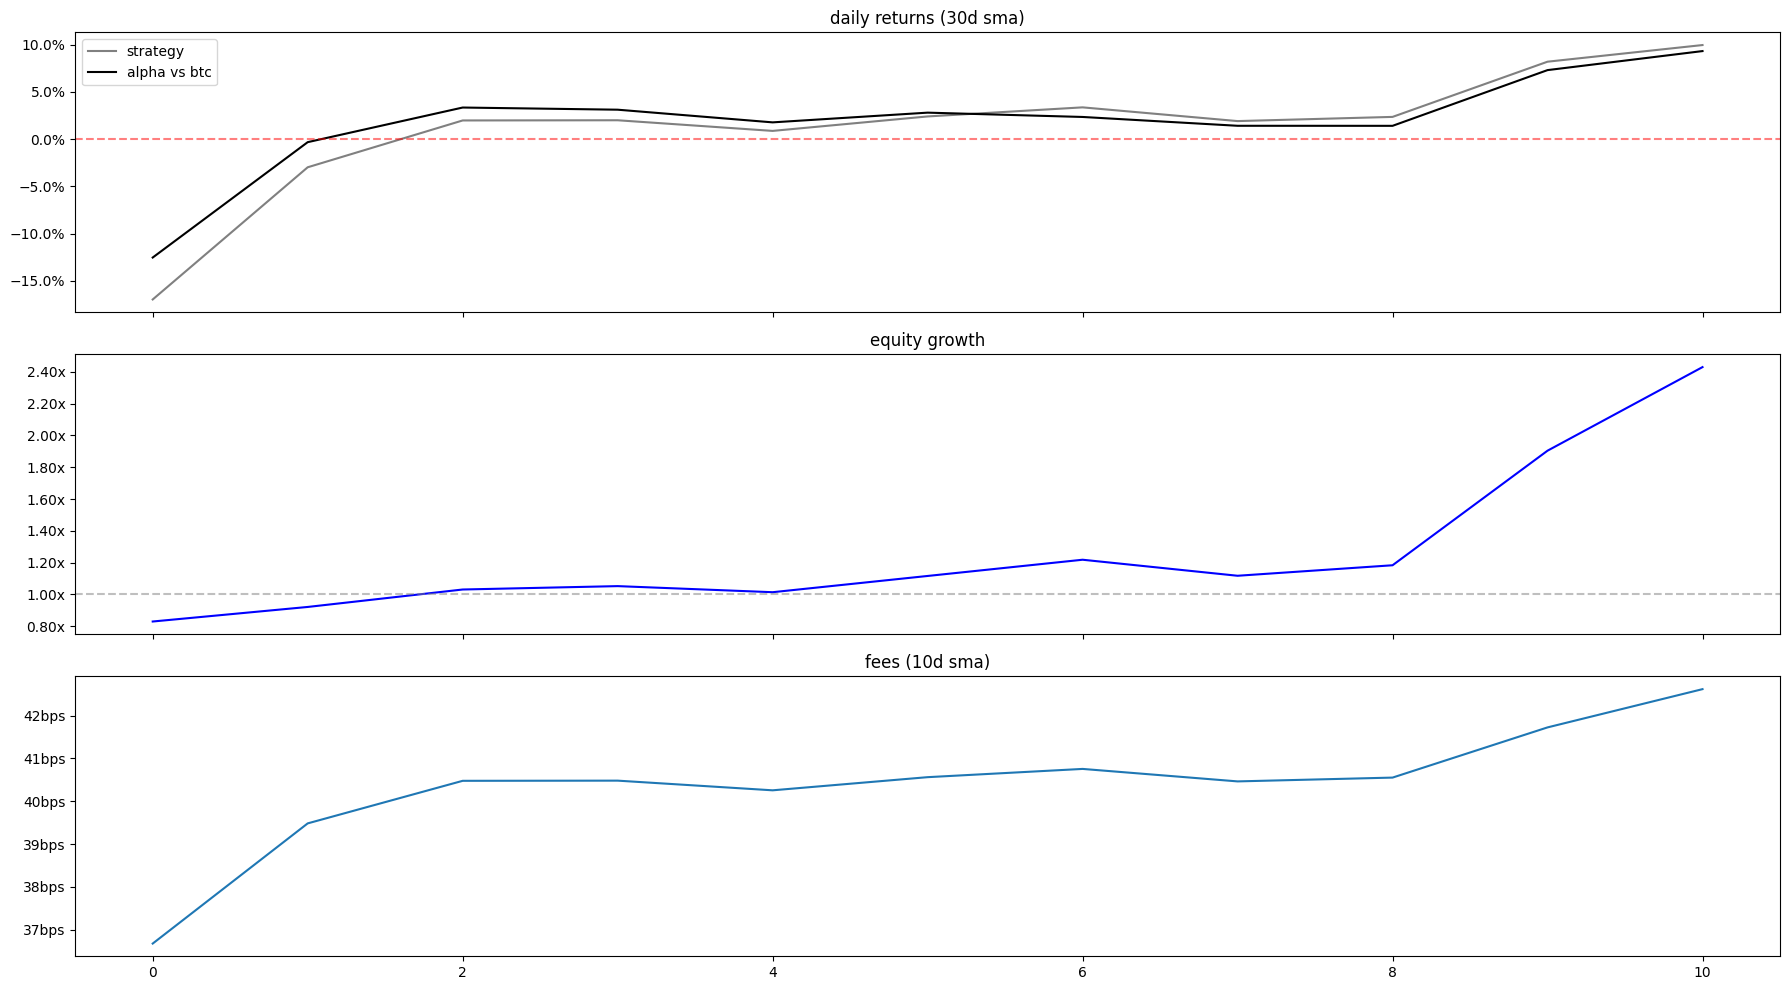

In [169]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

res = pd.read_parquet(output_eval_file)

fig, [ax1, ax2, ax3] = plt.subplots(3,1,figsize=(18,10), sharex=True)

# returns
((np.exp(res.strategy) - 1) * 100).rolling(30,min_periods=1).mean().plot(y='strategy',ax=ax1,color='gray',label='strategy')
((np.exp(res.perf) - 1) * 100).rolling(30,min_periods=1).mean().plot(y='perf',ax=ax1,color='black',label='alpha vs btc')
ax1.set_title('daily returns (30d sma)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(symbol='%'))
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.legend()

# equity multiplier
np.exp(res.equity).plot(y='equity',ax=ax2,color='blue',title='equity growth')
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.2f}x'))
ax2.axhline(1, color='gray', linestyle='--', alpha=0.5)

# fees
(res.fee * 10_000).rolling(10,min_periods=1).mean().plot(y='fee',ax=ax3,title='fees (10d sma)')
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f}bps'))
plt.tight_layout()
plt.show()

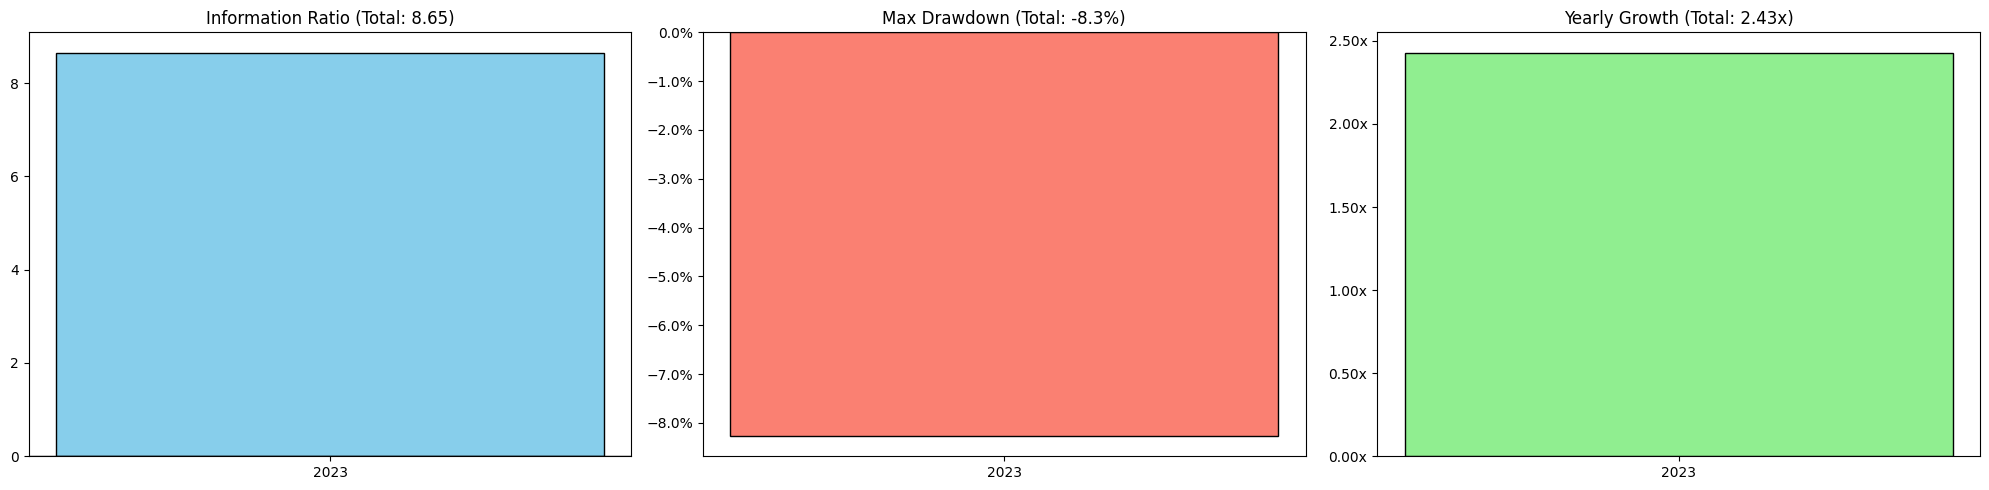

In [173]:
import scrapbook as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

res = pl.read_parquet(output_eval_file)

# 1. Prepare Yearly Metrics
# We use the 'strategy' (log ret) and 'perf' (log excess ret) columns
yearly_stats = (
    res.with_columns(pl.col('ts').dt.year().alias('year'))
    .group_by('year')
    .agg([
        # Annualized IR: (Mean Excess / Std Excess) * sqrt(365)
        ((pl.col('perf').mean() / (pl.col('perf').std() + 1e-9)) * np.sqrt(365)).alias('ir'),
        
        # Max Drawdown: Min of (Equity / Running Max - 1)
        ((pl.col('strategy').cum_sum().exp() / 
          pl.col('strategy').cum_sum().exp().cum_max()) - 1).min().alias('mdd'),
          
        # Growth Multiplier: exp(sum of log returns)
        (pl.col('strategy').sum().exp()).alias('growth')
    ])
    .sort('year')
)

# 2. Calculate Total Period Metrics
total_ir = (res['perf'].mean() / (res['perf'].std() + 1e-9)) * np.sqrt(365)
total_equity = res['strategy'].cum_sum().exp()
total_mdd = ((total_equity / total_equity.cum_max()) - 1).min()
total_growth = total_equity.tail(1).item()

# 3. Record Metrics for Papermill (using Scrapbook)
sb.glue("ir_total", float(total_ir))
sb.glue("mdd_total", float(total_mdd))
sb.glue("growth_total", float(total_growth))
sb.glue("yearly_stats", yearly_stats.to_pandas().to_dict(orient='records'))

# 4. Yearly Bar Chart Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
y_pd = yearly_stats.to_pandas()
years = y_pd['year'].astype(str)

# IR Chart
axes[0].bar(years, y_pd['ir'], color='skyblue', edgecolor='black')
axes[0].set_title(f'Information Ratio (Total: {total_ir:.2f})')
axes[0].axhline(0, color='black', lw=1)

# MDD Chart
axes[1].bar(years, y_pd['mdd'] * 100, color='salmon', edgecolor='black')
axes[1].set_title(f'Max Drawdown (Total: {total_mdd*100:.1f}%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Growth Multiplier
axes[2].bar(years, y_pd['growth'], color='lightgreen', edgecolor='black')
axes[2].set_title(f'Yearly Growth (Total: {total_growth:.2f}x)')
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.2f}x'))

plt.tight_layout()
plt.show()